In [1]:
from utilities import *
import matplotlib.pyplot as plt
import scipy

61


In [2]:
trans = lb.sequence.transition_loop(61, 0.9)
trans

array([[0.9       , 0.00166667, 0.00166667, ..., 0.00166667, 0.00166667,
        0.00166667],
       [0.00166667, 0.9       , 0.00166667, ..., 0.00166667, 0.00166667,
        0.00166667],
       [0.00166667, 0.00166667, 0.9       , ..., 0.00166667, 0.00166667,
        0.00166667],
       ...,
       [0.00166667, 0.00166667, 0.00166667, ..., 0.9       , 0.00166667,
        0.00166667],
       [0.00166667, 0.00166667, 0.00166667, ..., 0.00166667, 0.9       ,
        0.00166667],
       [0.00166667, 0.00166667, 0.00166667, ..., 0.00166667, 0.00166667,
        0.9       ]], shape=(61, 61))

In [3]:
y, sr = lb.load('data/tora.mp3')
y_harm, y_perc = lb.effects.hpss(y)

## Filtering the chromagram

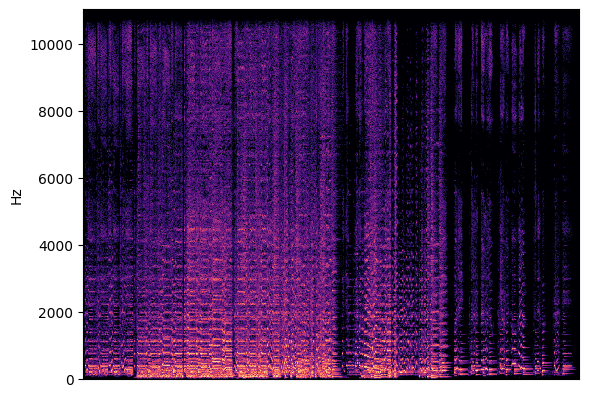

In [4]:
D = lb.amplitude_to_db(np.abs(lb.stft(y_harm)), ref=np.max)
lb.display.specshow(D, y_axis='hz')

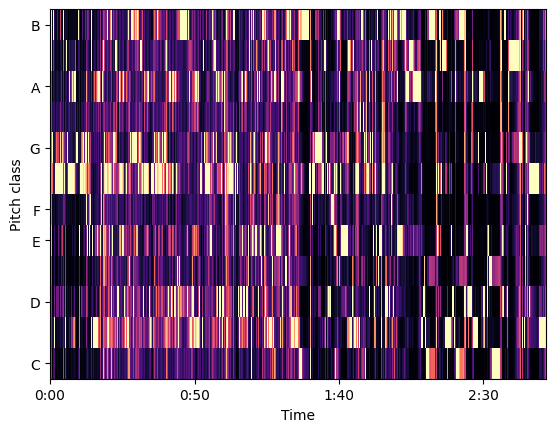

In [5]:
chromagram = lb.feature.chroma_cqt(y=y_harm, sr=sr)
lb.display.specshow(chromagram, y_axis='chroma', x_axis='time')

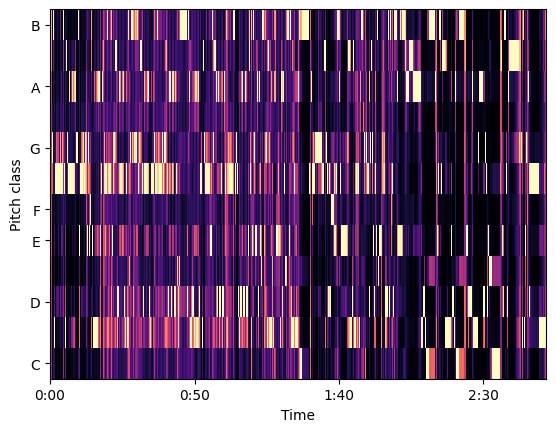

In [6]:
chroma_filter = np.minimum(chromagram,
                           lb.decompose.nn_filter(chromagram,
                                                       aggregate=np.median,
                                                       metric='cosine'))
lb.display.specshow(chroma_filter, y_axis='chroma', x_axis='time')

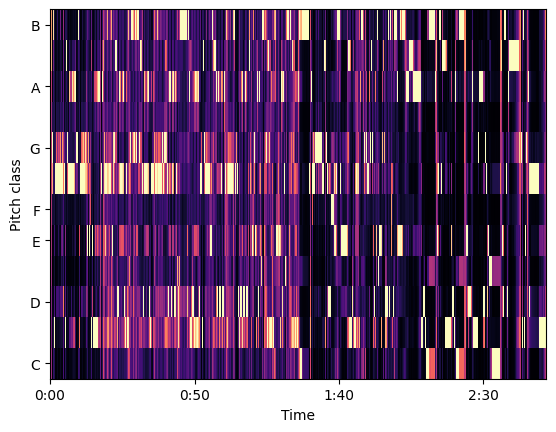

In [7]:
chroma_smooth = scipy.ndimage.median_filter(chroma_filter, size=(1, 9))
lb.display.specshow(chroma_smooth, y_axis='chroma', x_axis='time')

In [11]:
for i in range(0, len(labels), 4):
    print(', '.join(labels[i:i+4]))

C:maj, C#:maj, D:maj, D#:maj
E:maj, F:maj, F#:maj, G:maj
G#:maj, A:maj, A#:maj, B:maj
C:maj7, C#:maj7, D:maj7, D#:maj7
E:maj7, F:maj7, F#:maj7, G:maj7
G#:maj7, A:maj7, A#:maj7, B:maj7
C:min, C#:min, D:min, D#:min
E:min, F:min, F#:min, G:min
G#:min, A:min, A#:min, B:min
C:min7, C#:min7, D:min7, D#:min7
E:min7, F:min7, F#:min7, G:min7
G#:min7, A:min7, A#:min7, B:min7
C:normal7, C#:normal7, D:normal7, D#:normal7
E:normal7, F:normal7, F#:normal7, G:normal7
G#:normal7, A:normal7, A#:normal7, B:normal7
N


## Percussion

In [8]:
y_perc

array([1.7160213e-08, 4.7290891e-09, 1.3664436e-09, ..., 7.2535658e-15,
       1.4799959e-14, 9.5320760e-15], shape=(3785440,), dtype=float32)

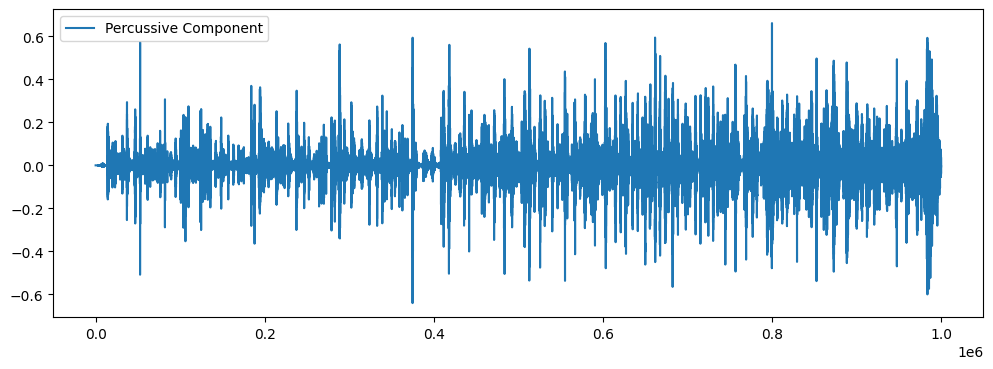

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(y_perc[0:1000000], label='Percussive Component')
plt.legend()
plt.show()

In [10]:
tempo, beats_static = lb.beat.beat_track(y=y, sr=sr, units='time', trim=False)

print(f"Tempo estimate: {tempo[0]:.2f} BPM")

Tempo estimate: 152.00 BPM
